# kNN with prediction for real-time data

The file `kNN_real_time_script.py` produces a forecast of wind power generation for a window (of maximum 3 days) input by the user. If the forecast window provided by the user falls under the already downloaded data, the script simply uses saved data to train and forecast. If the forecast window is outside the already downloaded data, the script downloads relevent rows of true data to train on for wind power output and weather data, along with the weather forecasting data for the forecasting window, trains a kNN model and makes a forecast. We have all the power and weather data already downloaded and saved till the date `2025-06-22` (or so). The model gets trained on a 60 day window prior to the first day of the forecast window. 
- The main function of the script `kNN_forecast_main()` returns an array of the predicted values and make a plot of total power per day showing the trained data, extended to the forecasted window.
- To download the wind power generation data outside the already downloaded time-frame, we use an API call using `power_api_call()` present inside the script.
- To download relevant weather data outside the already downloaded time-frame, we use an API call `weather_api_call()`, inside the script `real_time_weather_api.py`. This is done to enhance readability as this function is a bit lengthier.
- The newly downloaded data will not be saved (as of now).

WARNINGs: 
- Currently, we are missing the power data from 2024-01-01 till 2024-06-20 and the API key to download up-to-date real-time data for power generation (if we don't get that, we'll web scrap). So, I only ask the user to input a date between '2024-08-20' and '2025-06-22'.
- Duplicate handling functions are not written till now as the data in these range are nice. I'll write them later (shouldn't be hard).

In [1]:
from kNN_real_time_script import kNN_forecast_main


Please enter forecast start date in the format YYYY-MM-DD.The date should be in between 2024-08-20 to 2025-06-23.

You have entered: 2025-01-01.

Please enter forecast window (in days). It should be an integer between 1 or 3.

You have entered: 3

Your forecast window is days between: 2025-01-01 and 2025-01-03

Please wait. Plotting your forecast...


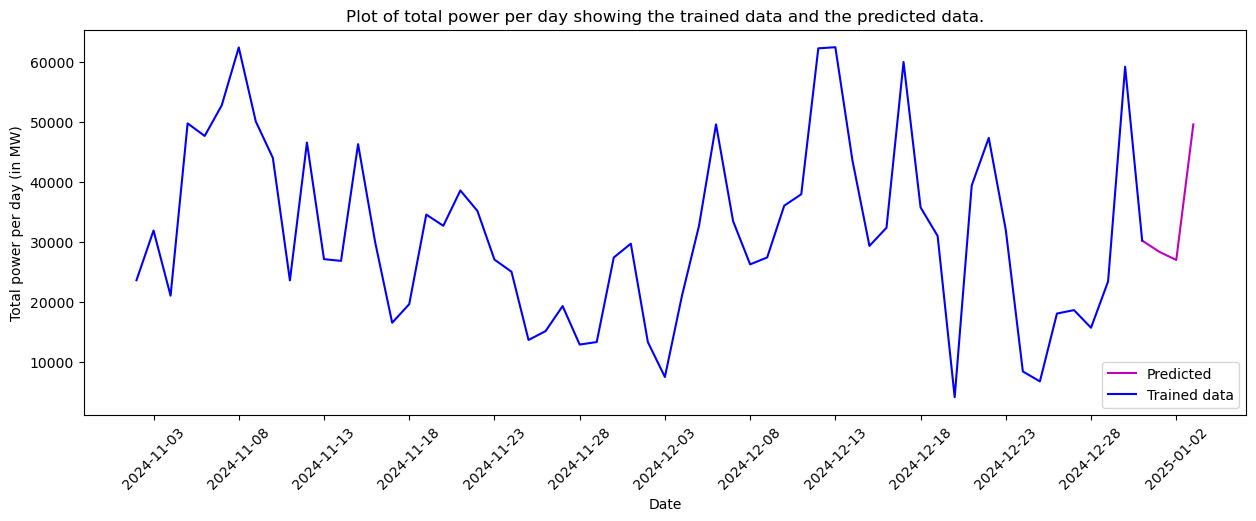

In [2]:
preds = kNN_forecast_main()



Please enter forecast start date in the format YYYY-MM-DD.The date should be in between 2024-08-20 to 2025-06-23.

You have entered: 2025-06-01.

Please enter forecast window (in days). It should be an integer between 1 or 3.

You have entered: 1

Your forecast window is days between: 2025-06-01 and 2025-06-01

Please wait. Plotting your forecast...


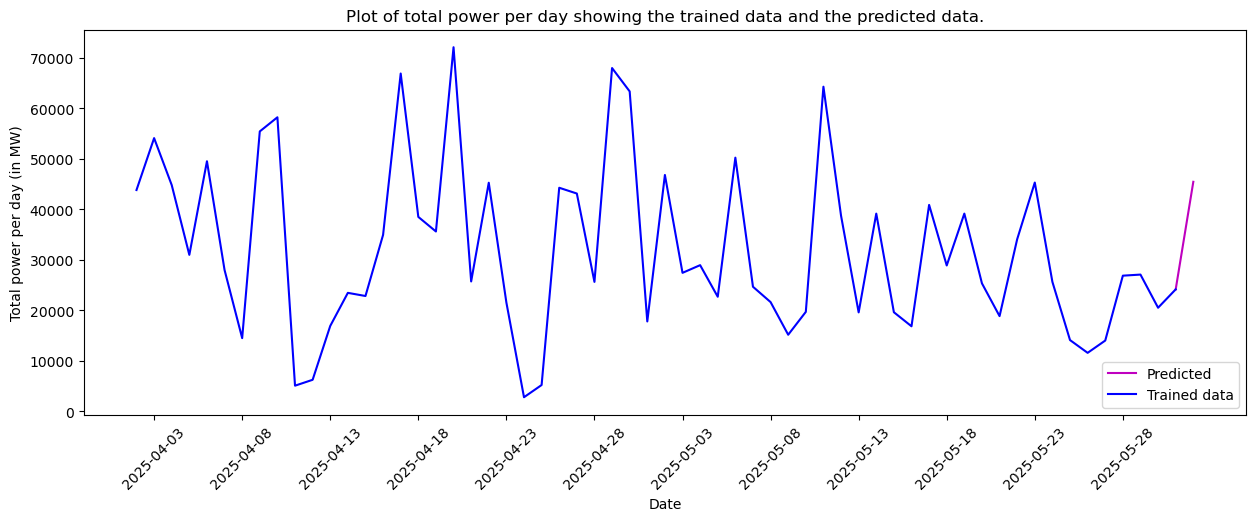

In [3]:
preds = kNN_forecast_main()

The rest of the notebook is just some trial or explanation of the codes present in .py file.

# Exaplanation for code in .py file

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from datetime import date
from real_time_weather_api import weather_api_call
from hydroquebec.api import Hydro_quebec_data
from typing import Tuple, List, Union, Dict

#### Read and clean power data

In [26]:
def read_and_clean_power_data(train_window: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Reads historical wind power data and filters it to match the training window.
    Automatically fetches new data from API if needed and handles duplicate timestamps.

    Args:
        train_window (pd.DatetimeIndex): Dates used for training (daily frequency).

    Returns:
        pd.DataFrame: Cleaned DataFrame containing 'time' and 'wind' columns.
    """

    power_df = pd.read_csv("already_downloaded_data/power_data.csv")[["time","wind"]]

    power_df['time'] = pd.to_datetime(power_df['time'])
    power_df['time'] = power_df['time'].apply(lambda x: x.floor('h'))
    power_df['time'] = power_df['time'].dt.tz_localize(None)

    train_window_hourly =  pd.date_range(train_window[0], 
                                            train_window[-1].replace(hour=23), freq='h')
    power_df = power_df[power_df['time'].isin(train_window_hourly)]
    power_df = power_df.sort_values('time')

    #Checking duplicate 'time' in the power dataset
    if len(power_df[power_df['time'].duplicated()]) != 0:
        print("Duplicates detected in power data. Calling duplicate handling funcion...")
        power_df = power_duplicate_handle(power_df)

    data_already_downloaded_till = pd.Timestamp('2025-06-20')     ## the date till which we already have the date available, 
                                                    ## setting '2025-06-20' for now
    if train_window[-1] <= data_already_downloaded_till: 
                                    ## if the predict window is before 'data_already_downloaded_till'
                                    ## we'll use the already downloaded data to train and predict.
                                    ## This will improve the runtime significantly as most of the data
                                    ## will already be downloaded apart from a few days
                                                        
        return power_df
    else:
        start = data_already_downloaded_till + pd.Timedelta(1, unit='d')
        end = train_window[-1].strftime('%Y-%m-%d')            
        new_rows =  power_api_call(start,end)
        new_rows['time'] = pd.to_datetime(new_rows['time'], utc =True)
        new_rows['time'] = new_rows['time'].apply(lambda x: x - pd.Timedelta(hours=5))
        new_rows['time'] = new_rows['time'].apply(lambda x: x.floor('h'))
        new_rows['time'] = new_rows['time'].dt.tz_localize(None)

        new_power_df = pd.merge(power_df, new_rows, on=['time'])
        if len(new_power_df[new_power_df['time'].duplicated()]) != 0:
            print("Duplicates detected in downloaded power data. Calling duplicate handling funcion...")
            new_power_df = power_duplicate_handle(new_power_df)
        return new_power_df

  
def power_duplicate_handle(df: pd.DataFrame, time_window: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Handles duplicate timestamps in the power data.

    Args:
        df (pd.DataFrame): Power data with potential duplicate timestamps.
        time_window (pd.DatetimeIndex): Time window for which data is being processed.

    Returns:
        pd.DataFrame: DataFrame with duplicates resolved.
    """
    #body of the implementation here
    return df


def power_api_call(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Fetches wind generation data from the Hydro Quebec API for the given date range.

    Args:
        start_date (str): Start date in 'YYYY-MM-DD' format.
        end_date (str): End date in 'YYYY-MM-DD' format.

    Returns:
        pd.DataFrame: DataFrame containing hourly wind power data.
    """ 
    api_key = 'API_key_here'
    data_type = 'generation'
    data_frame = Hydro_quebec_data(api_key, data_type, start_date, end_date)
    return data_frame ### may need to convert to pd.Dataframe as the api call may return a dictionary

#### Read and clean the weather data

In [25]:
def read_and_clean_weather_data(train_window: pd.DatetimeIndex, predict_window: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Reads and preprocesses weather data for both training and prediction windows. 
    Automatically fetches new data from API if needed and handles duplicate timestamps.

    Args:
        train_window (pd.DatetimeIndex): Date range used for training the model.
        predict_window (pd.DatetimeIndex): Date range for which predictions will be made.

    Returns:
        pd.DataFrame: Cleaned and complete weather data for the combined time window.
    """

    weather_df = pd.read_csv("already_downloaded_data/weather_data.csv")

    train_window = list_of_days(train_window)
    predict_window = list_of_days(predict_window)
    time_window = pd.to_datetime(train_window + predict_window)

    weather_df['time'] = pd.to_datetime(weather_df['time'])
    weather_df['time'] = weather_df['time'].dt.tz_localize(None)
    weather_df['time'] = weather_df['time'].apply(lambda x: x.floor('h'))

    time_window_hourly = pd.date_range(time_window[0], time_window[-1].replace(hour=23), freq='h')
    weather_df = weather_df[weather_df['time'].isin(time_window_hourly)]
    weather_df = weather_df.sort_values('time')

    #Checking duplicate 'time' in the power dataset
    if len(weather_df[weather_df['time'].duplicated()]) != 0:
        print("Duplicates detected in weather data. Calling duplicate handling funcion...")
        weather_df = weather_duplicate_handle(weather_df, time_window)

    data_already_downloaded_till = pd.Timestamp('2025-06-20') 
    if time_window[-1] <= data_already_downloaded_till: ## if the predict window is before '2025-06-20'
                                                        ## we'll use the already downloaded data to train and predict.
                                                        ## This will improve the runtime significantly as most of the data
                                                        ## will already be downloaded apart from a few days 
        return weather_df
    else:           ## if some rows don't exist, download them, merge and return the new dataframe
        start = data_already_downloaded_till + pd.Timedelta(1,unit='d') 
        end = time_window[-1].strftime('%Y-%m-%d')
        new_rows = weather_api_call(start, end)
        new_rows['time'] = pd.to_datetime(new_rows['time'], utc =True)
        new_rows['time'] = new_rows['time'].apply(lambda x: x - pd.Timedelta(hours=5))
        new_rows['time'] = new_rows['time'].apply(lambda x: x.floor('h'))
        new_rows['time'] = new_rows['time'].dt.tz_localize(None)

        new_weather_df = pd.merge(weather_df, new_rows, on= ['time'])
        if len(new_weather_df[new_weather_df['time'].duplicated()]) != 0:
            print("Duplicates detected in downloaded weather data. Calling duplicate handling funcion...")
            new_weather_df = weather_duplicate_handle(new_weather_df, time_window)
        return new_weather_df

    
def weather_duplicate_handle(df: pd.DataFrame, time_window: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Handles duplicated timestamps in weather data within a specified time window.

    Args:
        df (pd.DataFrame): DataFrame possibly containing duplicate timestamps.
        time_window (pd.DatetimeIndex): Time window to constrain the check.

    Returns:
        pd.DataFrame: Cleaned DataFrame without duplicate timestamps.
    """

    ## body of the code here
    return df

#### Interactively ask user to input forcast window

In [ ]:
def get_forecast_window() -> pd.DatetimeIndex:
    """
    Interactively prompts the user to input a forecast window.

    Returns:
        pd.DatetimeIndex: A pandas date range between selected start and end date.
    """
    earliest_allowed_date = pd.Timestamp('2024-08-20')
    latest_allowed_date = pd.Timestamp(f'{str(date.today())}')
    print(f"\nPlease enter forecast start date in the format YYYY-MM-DD." 
          f"The date should be in between {earliest_allowed_date.strftime('%Y-%m-%d')}"
          f" to {latest_allowed_date.strftime('%Y-%m-%d')}.")
    date_str= input("Input the start date now: ")
    try:
        year, month, day = int(date_str[:4]), int(date_str[5:7]), int(date_str[8:])
        start_date = pd.Timestamp(year=year, month=month, day=day)
        assert earliest_allowed_date <= start_date <= latest_allowed_date, ("ValueError: "
        f"Please input a date between {earliest_allowed_date.strftime('%Y-%m-%d')}"
        f" to {latest_allowed_date.strftime('%Y-%m-%d')}.")
    except ValueError:
        raise AssertionError(f"Invalid date: {year}-{month}-{day}")
    print(f"\nYou have entered: {start_date.strftime('%Y-%m-%d')}.")

    window_length = 3
    print(f"\nPlease enter forecast window (in days). It should be an integer between 1 or {window_length}.")
    
    window = int(input("Input forecast window: "))
    assert 1 <= window <= window_length, f"ValueError: Input should be an integer between 1 or {window_length}."

    print(f"\nYou have entered: {window}")

    end_date = start_date + pd.Timedelta(window-1, unit='d')
    predict_window = pd.date_range(start=start_date, end=end_date, freq='d')
    
    print(f"\nYour forecast window is days between: {predict_window[0].strftime('%Y-%m-%d')} "
          f"and {predict_window[-1].strftime('%Y-%m-%d')}\n")
    return predict_window

In [41]:
earliest_allowed_date = pd.Timestamp('2024-08-20')
latest_allowed_date = pd.Timestamp(f'{str(date.today())}')
start_date = pd.Timestamp('2024-08-25')
date_str= input("Input the start date now: ")
year, month, day = int(date_str[:4]), int(date_str[5:7]), int(date_str[8:])
print(year, month, day)
start_date = pd.Timestamp(year=year, month=month, day=day)
print(start_date)
print(earliest_allowed_date <= start_date )

2024 8 25
2024-08-25 00:00:00
True


In [40]:
latest_allowed_date = pd.Timestamp(f'{str(date.today())}')
print(latest_allowed_date)

2025-06-23 00:00:00


#### Adjust the training window based on the user input

In [23]:
def get_train_window(predict_window: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """
    Computes the time window to train on: 60 days before the forecast window, 
    or starting from 2019-01-01 if the forecast is too early.

    Args:
        predict_window (pd.DatetimeIndex): The window to predict on.
    
    Returns:
        train_window (pd.DatetimeIndex): The training dataset window.
    """
    days_to_train_on = 60
    predict_start_date = predict_window[0]
    time_diff = predict_start_date - pd.Timestamp(year=2019,month=1,day=1)
    if time_diff.days <= days_to_train_on:
        train_start_date = pd.Timestamp(year=2019,month=1,day=1)
    else:
        train_start_date = predict_start_date - pd.Timedelta(days_to_train_on, unit='d')
    train_window = pd.date_range(start= train_start_date, 
                                 end= predict_start_date - pd.Timedelta(1, unit='d'), freq='d')
    return train_window    

In [47]:
pdf = pd.read_csv("already_downloaded_data/power_data.csv")
wdf = pd.read_csv("already_downloaded_data/weather_data.csv")

In [49]:
rows_with_nan = pdf[pdf.isnull().any(axis=1)]
print(rows_with_nan)


                     time  hydroelectric  wind  others  solar  thermal
237   2024-06-30T21:30:00            NaN   NaN     NaN    NaN        0
238   2024-06-30T22:30:00            NaN   NaN     NaN    NaN        0
239   2024-06-30T23:30:00            NaN   NaN     NaN    NaN        0
6261  2025-03-08T21:30:00            NaN   NaN     NaN    NaN        0
6266  2025-03-09T02:30:00            NaN   NaN     NaN    NaN        0


#### Call the previous functions to return train, forecast windows and the dataframes

In [22]:
def merge_power_weather_for_appropriate_time_window() -> (
        Tuple[pd.DatetimeIndex, pd.DatetimeIndex, pd.DataFrame, pd.DataFrame]):
    """
    Combines cleaned power and weather data for both training and prediction periods.

    Returns:
        Tuple[pd.DatetimeIndex, pd.DatetimeIndex, pd.DataFrame, pd.DataFrame]: 
            train_window: Date range for training.
            predict_window: Date range for prediction.
            train_df: Merged DataFrame for training.
            predict_df: Weather-only DataFrame for prediction (no wind power).
    """
    predict_window = get_forecast_window()
    train_window = get_train_window(predict_window)

    power_df = read_and_clean_power_data(train_window)          ## already only has the training data
    weather_df = read_and_clean_weather_data(train_window, predict_window)
    
    weather_df_train = weather_df[weather_df['time'].isin(pd.date_range(train_window[0], 
                                            train_window[-1].replace(hour=23), freq='h'))]
    train_df = pd.merge(power_df, weather_df_train, on=['time'])

    predict_df= weather_df[weather_df['time'].isin(pd.date_range(predict_window[0], 
                                            predict_window[-1].replace(hour=23), freq='h'))]    
                ## assuming in real-time case, we won't have the wind power column in the predict_df
                ## that's the entire point that we are predicting anyway
    return train_window, predict_window, train_df, predict_df


#### Make the feature (wind speed)^3 divided by temperature and drop others

In [21]:
def speed_cubed_div_temp(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature engineering step: Computes (wind_speed^3) / (temperature in Kelvin) for each farm.

    Args:
        df (pd.DataFrame): Input DataFrame with wind speed and temperature columns for 39 farms.

    Returns:
        pd.DataFrame: Modified DataFrame with new features added and original weather columns dropped.
    """    
    new_cols = []
    for i in range(1, 40):
        spd_col = f'wind_speed_10m_{i}'
        temp_col = f'temperature_2m_{i}'
        final_col = (df[spd_col] ** 3)/ (df[temp_col].values + 273) #divide by temperature in Kelvin scale   
        new_cols.append(pd.DataFrame({
            f'{spd_col}_cubed_div_temp': final_col
        }))

    df_new = pd.concat([df.drop(columns= [f'wind_speed_10m_{i}' for i in range(1, 40)] +
                                [f'temperature_2m_{i}' for i in range(1,40)] +
                                [f'wind_direction_10m_{i}' for i in range(1,40)]+
                                [f'relative_humidity_2m_{i}' for i in range(1,40)], errors='ignore')] + new_cols, axis=1)
    return df_new.copy()

## The main function to forecast

In [20]:
def kNN_forecast_main(pca_comp: int = 35, n_nbr: int = 5 ) -> List[float]:
    """
    Runs the kNN pipeline on weather and power data: reads, preprocesses, trains, predicts, and plots.

    Args:
        pca_comp (int): Number of PCA components to use for dimensionality reduction.
        n_nbr (int): Number of neighbors to use for kNN regression.

    Returns:
        List[float]: Daily forecasted values.
    """

    train_window, predict_window, train_df, predict_df = merge_power_weather_for_appropriate_time_window()
    print("Please wait. Plotting your forecast...")
    train_df = speed_cubed_div_temp(train_df)
    predict_df = speed_cubed_div_temp(predict_df)

    features = train_df.columns.drop(['Unnamed: 0.1','Unnamed: 0', 'time', 'Year', 'YearMonthDay', 'wind'], 
                                     errors='ignore')

    pipe = Pipeline([('scale', StandardScaler()), ('pca', PCA(n_components= pca_comp))])
    pipe.fit(train_df[features])

    pca_train = pipe.transform(train_df[features])
    pca_predict = pipe.transform(predict_df[features])

    knn = KNeighborsRegressor(n_neighbors=n_nbr)
    knn.fit(pca_train, train_df.wind)
    pred = knn.predict(pca_predict)

    trained_on = np.array(train_df.wind)
    trained_on = [sum(trained_on[i:i+24]) for i in range(0,len(trained_on),24)] ## aggregate of each day 

    predicted = [sum(pred[i:i+24]) for i in range(0, len(pred),24)] ## add all the hourly data to get the aggregate for each day
    plot(predicted, trained_on, train_window, predict_window)       ## make the plot
    return predicted


In [43]:
pred = kNN_forecast_main()


Please enter forecast start date in the format YYYY-MM-DD.The date should be in between 2024-08-20 to 2025-06-23.

You have entered: 2024-08-25.

Please enter forecast window (in days). It should be an integer between 1 or 3.

You have entered: 3

Your forecast window is days between: 2024-08-25 and 2024-08-27

Please wait. Plotting your forecast...


ValueError: Input y contains NaN.

#### Some helper functions

In [19]:
def list_of_days(time_window: pd.DatetimeIndex) -> List[str]:
    """
    Provides a list of string-formatted dates (YYYY-MM-DD) from a given DatetimeIndex.

    Args:
        time_window (pd.DatetimeIndex): Array of pandas timestamps.

    Returns:
        List[str]: List of dates in 'YYYY-MM-DD' string format.
    """
    assert isinstance(time_window, pd.DatetimeIndex), ("TypeError: "
                                "time_window must be of type pandas.core.indexes.datetimes.DatetimeIndex.")
    return [x.strftime('%Y-%m-%d') for x in time_window]


def plot(preds: List[float], trained_on: List[float], train_window: pd.DatetimeIndex, 
         predict_window: pd.DatetimeIndex) -> None:
    """
    Plots historical (true values), then extends on the same plot forecasted daily power 
    output over a time range.

    Args:
        preds (List[float]): Predicted daily power output values.
        trained_on (List[float]): Historical aggregate power values used for training.
        train_window (pd.DatetimeIndex): Timestamps corresponding to training data.
        predict_window (pd.DatetimeIndex): Timestamps corresponding to prediction days.
    """
    fig, ax = plt.subplots(1, 1, figsize=(15, 5))

    train_day_strings = [x.strftime('%Y-%m-%d') for x in train_window] 
    predict_day_strings = [x.strftime('%Y-%m-%d') for x in predict_window]
    all_days_strings = train_day_strings + predict_day_strings
    days = pd.to_datetime(all_days_strings)

    preds = [trained_on[-1]] + preds
    predict_day_strings = [train_day_strings[-1]] + predict_day_strings
    predict_day_strings = pd.to_datetime(predict_day_strings)
    ax.plot(predict_day_strings, preds, label = "Predicted", color = 'm')

    ax.plot(train_window, trained_on, label = 'Trained data', color = 'b')
    ax.legend(loc='lower right')
    ax.tick_params(axis='x', rotation = 45)
    ax.set_xticks([days[i] for i in range(1,len(days),len(days)// 12)])
    ax.set_xlabel('Date')
    ax.set_ylabel('Total power per day (in MW)')
    ax.set_title("Plot of total power per day showing the trained data and the predicted data.")

    plt.show()

## To download weather_data from 2024-01-01 to 2025-06-22

In [ ]:
## To download historic weather data between 2024-01-01 till 2025-06-22

import time
import requests
import pandas as pd
from typing import List, Dict, Optional
import os

#Function to slow down requests to avoid rate limit on the API
def fetch_with_retry(url, params, max_retries=3):
    for _ in range(max_retries):
        response = requests.get(url, params=params)
        if response.status_code == 200:
            return response.json()
        elif response.status_code == 429:
            wait_time = int(response.headers.get("Retry-After", 10))
            print(f"Rate limited. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)
        else:
            print(f"Error {response.status_code}: {response.text}")
            break
    return None


def fetch_historical_weather_multiple(
    latitudes: List[float],
    longitudes: List[float],
    start_datetime: str,
    end_datetime: str,
    location_names: Optional[List[str]] = None,
) -> Dict[str, pd.DataFrame]:
    """
    Fetch historical weather data for multiple lat/lon pairs, including wind direction.

    Args:
        latitudes: List of latitudes.
        longitudes: List of longitudes.
        start_date: Start date in "YYYY-MM-DD" format.
        end_date: End date in "YYYY-MM-DD" format.
        location_names: Optional names for each location (default: "loc_0", "loc_1", ...).

    Returns:
        Dictionary of DataFrames (key: location name, value: weather data).
    """
    start_date = start_datetime.split("T")[0]
    end_date = end_datetime.split("T")[0]

    if len(latitudes) != len(longitudes):
        raise ValueError("Latitudes and longitudes must have the same length.")
    
    if location_names is None:
        location_names = [f"loc_{i}" for i in range(len(latitudes))]
    elif len(location_names) != len(latitudes):
        raise ValueError("Location names must match latitudes/longitudes length.")

    weather_data = {}
    base_url = "https://archive-api.open-meteo.com/v1/archive"         ## for archived data
    #base_url = "https://api.open-meteo.com/v1/forecast"                 ## for forcasted data

    for lat, lon, name in zip(latitudes, longitudes, location_names):
        params = {
            "latitude": lat,
            "longitude": lon,
            "start_date": start_date,
            "end_date": end_date,
            "hourly": [
                "temperature_2m",
                "wind_speed_10m",
                "relative_humidity_2m"
            ],
            "timezone": "UTC"
        }
        
        data = fetch_with_retry(base_url, params=params,max_retries=5)

        df = pd.DataFrame(data["hourly"])
        df['time'] = pd.to_datetime(df['time'], utc=True)
        time_filter = (df["time"] >= start_datetime) & (df["time"] <= end_datetime)
        df["location"] = name 
        df = df[time_filter]
        df['time'] = df['time'] - pd.Timedelta(hours=5)
        weather_data[name] = df

    return weather_data

## Setting up the required varibales to call the above function
position_df = pd.read_csv(r'../../data/raw_data/hydroquebec_wind_farms_in_service.csv')
# Example: Montreal (45.5017° N, 73.5673° W)
latitude = position_df['latitude']
longitude = position_df['longitude']
start_date = '2024-01-01'
end_date = '2025-06-23'
start_date += "T05:00:00"     ## adjusting for the time-zone to UTC conversion     
end_date += "T04:00:00"
weather_data = fetch_historical_weather_multiple(latitude, longitude, start_date, 
                                                     end_date,location_names=position_df['name'])

In [29]:

keys = [x for x in weather_data.keys()]
merge_wdf = pd.DataFrame()
for key, label in zip(keys, position_df["labels"]):
    df = pd.DataFrame(weather_data[key])
    
    new_columns = [f"{column}" for column in df.columns[0:1]] + [f"{column}_{label}" for column in df.columns[1:]]
    df.columns = new_columns
    df = df.drop(columns=[new_columns[-1]])                    ## drop the location, no need anymore
    df['time'] = pd.to_datetime(df['time'])                 ## convert time to pandas timestamp
    df = df.sort_values('time')   
    if key == keys[0]:
        merge_wdf = df
    else:
        merge_wdf = pd.merge(merge_wdf, df, on=['time'])
merge_wdf = merge_wdf.dropna()
merge_wdf.to_csv("already_downloaded_data/weather_data.csv")